In [123]:
### STEP 1:IMPORT IMAGES AND LANDMARK FILES

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
import os
import re
from PIL import Image

os.chdir("C:/Users/Jason Mares/Documents/VizDezI")

out_dir = 'py_output/'
r_dir ='r_output/'

paths = ["12mo_270a8", "12mo_299a3"]
samples=paths

n_features = 16

### Reference landmarks refer to Visium landmarks
### Query landmarks refer to DESI landmarks

# Read images and landmarks
query_images = [cv2.imread(str(r_dir+path+"_hires_image.png")) for path in paths]
query_landmarks = pd.read_csv(r_dir + 'Query_Reference_Landmarks_for_Visium_Data.csv', index_col=[0, 1])
query_landmarks = query_landmarks.sort_values(['sample_ID'])

arr = os.listdir(r_dir)
reference_files = [file for file in arr if re.search("pos.+_4|neg.+_3",file)]
reference_landmarks = pd.read_csv(r_dir + 'Query_Reference_Landmarks_for_DESI_Data.csv', index_col=[0, 1])
reference_landmarks = reference_landmarks.sort_values(["sample_ID","charge"])

# Prin t unique image files of DESI Data
from functools import reduce
def unique(list1): 
    # Print directly by using * symbol
    ans = reduce(lambda re, x: re+[x] if x not in re else re, list1, [])
    return(ans)

print(unique(reference_landmarks.image_file))


['AL081523_Laura_270_a8_WT_12mo_slide2_s1_neg on DESI HDMS_TL_to_image_3.png', 'AL081123_Laura_270_a8_WT_12mo_s3_pos on DESI HDMS_TL_to_image_4.png', 'AL081323_Laura_299_a3_Tg_12mo_RE_s5_neg on DESI HDMS_TL_to_image_3.png', 'AL081123_Laura_299_a3_Tg_12mo_s3_pos on DESI HDMS_TL_to_image_4.png']


In [118]:
# Functions that perform the alignment and image transformations

def calculate_homography_matrix(reference_coords, query_coords):
    # keep only coordinate columns
    
    reference_coords = reference_coords.filter(regex='V')
    query_coords = query_coords.filter(regex='V')

    # want reference coords to have full complement
    ref_isna = reference_coords.isna()
    query_isna = query_coords.isna()
    assert not any(ref_isna.iloc[0] | ref_isna.iloc[1])

    # keep only shared landmarks
    to_keep = ~(ref_isna.iloc[0] | ref_isna.iloc[1] | query_isna.iloc[0] | query_isna.iloc[1])
    reference_coords = reference_coords.loc[:, to_keep]
    query_coords = query_coords.loc[:, to_keep]

    reference_coords = reference_coords.values.transpose()
    query_coords = query_coords.values.transpose()

    return cv2.findHomography(query_coords, reference_coords, method = 0)[0], (reference_coords, query_coords)
 

def transform_points(points, mat):
    return cv2.perspectiveTransform(points.reshape(-1, 1, 2), mat).reshape(-1, 2)

# Function for dealing with image dimension syntax
def Reverse(tuples):
    new_tup = tuples[::-1]
    return new_tup

In [127]:
sign = 'pos' # change between 'neg' and 'pos' then re-run bottom part

In [128]:
# STEP 2 - Image alignment and transformations

# Read DESI images
reference_images = [cv2.imread(r_dir+file) for file in unique(reference_landmarks[reference_landmarks.charge.str.contains(sign,regex=True)].image_file)]

#Find the best transformation between Visium and DESI using landmarks 
temp = [calculate_homography_matrix(query_coords = query_landmarks.iloc[(2*i):(2*i+2),:],
                                    reference_coords=reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].iloc[(2*i):(2*i+2),:]) 
        for i in list(range(len(reference_images)))]

mats, coord_sets = zip(*temp)

# Transform Visium images + landmarks into DESI space
images_transformed = [cv2.warpPerspective(src=query_images[i],
                                          M=mats[i],
                                          dsize=tuple([reference_images[i].shape[0],reference_images[i].shape[1]])[::-1]) 
                      for i in range(len(reference_images))]

landmarks_transformed = [transform_points(landmark, mat) for (_, landmark), mat in zip(coord_sets, mats)]

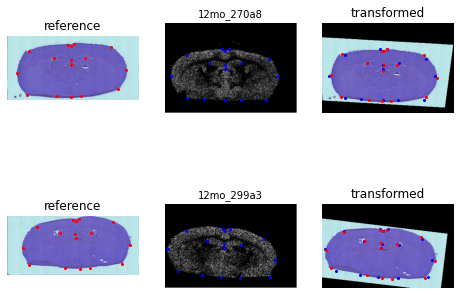

In [129]:
# STEP 3-  Plot images and landmarks, Visium, DESI, and transformed images + landmarks

nrow=2
import re
# plt.figure(figsize=(8, nrow*3))
plt.figure(figsize=(8,nrow*3))
for i, (sample, (reference_coords, query_coords), landmark_transformed, img, img_transformed, ref_image) in enumerate(zip(samples,
                                                                                                               coord_sets, landmarks_transformed, reference_images,
                                                                                                                          images_transformed,query_images)):
    
    plt.subplot(nrow,3,3*i+1)
    plt.title('reference')
    plt.imshow(ref_image)
    plt.plot(query_landmarks.filter(regex='V').iloc[(2*i),:].values,
         query_landmarks.filter(regex='V').iloc[(2*i+1),:].values,'ro',markersize=2)
    plt.axis('off')

    # image to transform
    plt.subplot(nrow,3,3*i+2)
    plt.title(re.sub("","",sample), fontsize=10)
    plt.imshow(img)
    plt.plot(reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i),:].values,
         reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i+1),:].values,'bo',markersize=2)
    plt.axis('off')

    # transformed image
    plt.subplot(nrow,3,3*i+3)
    plt.title('transformed')
    plt.imshow(img_transformed)
    plt.plot(reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i),:].values,
        reference_landmarks[reference_landmarks.charge.str.contains(sign, regex=True)].filter(regex='V').iloc[(2*i+1),:].values,'bo',markersize=2)
    # plt.plot(query_landmarks.iloc[(2*i),1:n_features].values,query_landmarks.iloc[(2*i+1),1:n_features].values,'ro',markersize=2)
    plt.plot(pd.DataFrame(landmark_transformed).iloc[:,0],
             pd.DataFrame(landmark_transformed).iloc[:,1],'o',c="red",markersize=2)
    plt.axis('off')
    

plt.savefig(out_dir+'Transformation_'+sign+'.pdf', dpi =400)

In [130]:
# STEP 4 - Link each spot to a pixel in DESI space

# Load in spots and their coordinates
spots_coords = pd.read_csv('r_output/spots_coords_hi_res.csv')
spots_coords['imagerow'] = round(spots_coords['imagerow'])
spots_coords['imagecol'] = round(spots_coords['imagecol'])
spots_coords[["imagerow", "imagecol"]] = spots_coords[["imagerow", "imagecol"]].astype("int")
spots_coords.imagerow = spots_coords.imagerow/1.0
spots_coords.imagecol = spots_coords.imagecol/1.0

# Transform point into another space (in this case DESI image space)
def transform_row(list_input,mat):
    res = transform_points(np.array(list_input), mat)
    if len(res[0])==2:
        return(res[0][0],res[0][1])
    else:
        return(0,0)
sorter = unique(query_landmarks.sample_ID)
print(sorter)
spots_coords["transformed_row"]= 1.0
spots_coords['transformed_col']= 1.0

# For each spot's center coordinates, find its linked DESI pixel coordinates
for i in range(spots_coords.shape[0]):
#    print(i)
    j= sorter.index(spots_coords.slice[i])
    name = sorter[j]
    mat = mats[j]
    res1,res2 =  transform_row(list(spots_coords.loc[i,['imagecol','imagerow']]),mat)   
    spots_coords.loc[i,'transformed_col'] = res1
    spots_coords.loc[i,'transformed_row'] = res2


spots_coords.to_csv(out_dir + "spots_coords_ion_pixels_"+sign+".csv")  


['12mo_270a8', '12mo_299a3']
